## Inventory optimisation & analysis:

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("data used/processed_supply_chain.csv")
df.head()

,date,sku_id,warehouse_id,supplier_id,region,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,...,inventory_value,reorder_needed,inventory_difference,year,month,month_name,quarter,day,day_of_week,day_name
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,...,8258.40,0,213,2024,1,January,1,1,0,Monday
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,...,8021.25,0,196,2024,1,January,1,2,1,Tuesday
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,...,7533.00,0,161,2024,1,January,1,3,2,Wednesday
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,...,7198.20,0,137,2024,1,January,1,4,3,Thursday
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,...,6905.25,0,116,2024,1,January,1,5,4,Friday


- creating SKU-Warehouse level dataset for inventory:

In [3]:
inventory_df = (df.groupby(['warehouse_id', 'sku_id']).agg({
        'inventory_level': 'last',
        'units_sold': ['mean', 'std'],
        'supplier_lead_time_days': 'mean',
        'unit_cost': 'mean',
        'unit_price': 'mean'}))

inventory_df.columns= ['current_inventory','avg_daily_demand','demand_std','lead_time','unit_cost','unit_price']
inventory_df= inventory_df.reset_index()

inventory_df.head()

,warehouse_id,sku_id,current_inventory,avg_daily_demand,demand_std,lead_time,unit_cost,unit_price
0,WH_1,SKU_1,624,20.471233,8.926893,14.0,13.95,20.48
1,WH_1,SKU_10,503,20.019178,9.155384,13.0,12.67,18.73
2,WH_1,SKU_11,758,19.956164,9.105200,4.0,19.54,34.79
3,WH_1,SKU_12,304,20.290411,9.264907,5.0,5.36,7.17
4,WH_1,SKU_13,442,20.449315,8.955370,9.0,19.52,24.09


- calculating safety stock assuming 95% service level

In [4]:
Z= 1.65
inventory_df['safety_stock']= (Z*inventory_df['demand_std']*np.sqrt(inventory_df['lead_time']))

- evaluating demand during lead time:

In [5]:
inventory_df['lead_time_demand']= (inventory_df['avg_daily_demand'] *inventory_df['lead_time'])

- reorder point:

In [6]:
inventory_df['recommended_reorder_point']= (inventory_df['lead_time_demand']+inventory_df['safety_stock'])

- recommending order quantity:

In [7]:
inventory_df['recommended_order_qty']= (inventory_df['recommended_reorder_point']-inventory_df['current_inventory'])
inventory_df['recommended_order_qty']= (inventory_df['recommended_order_qty'].clip(lower=0).round())

- inventory gap

In [10]:
inventory_df['inventory_gap'] = inventory_df['current_inventory']-inventory_df['recommended_reorder_point']

- inventory status:

In [11]:
def inventory_status(row):
    if row['current_inventory'] < row['recommended_reorder_point']:
        return 'Reorder Immediately'
    elif row['current_inventory'] > row['recommended_reorder_point'] * 1.5:
        return 'Overstock'
    else:
        return 'Healthy'

inventory_df['inventory_status'] = inventory_df.apply(inventory_status, axis=1)

- excess inventory value:


In [12]:
inventory_df['excess_units']= np.where(inventory_df['inventory_gap']>0, inventory_df['inventory_gap'],0)

inventory_df['excess_inventory_value']= inventory_df['excess_units']*inventory_df['unit_cost']

In [13]:
inventory_df.head()

,warehouse_id,sku_id,current_inventory,avg_daily_demand,demand_std,lead_time,unit_cost,unit_price,safety_stock,lead_time_demand,recommended_reorder_point,recommended_order_qty,inventory_status,inventory_gap,excess_units,excess_inventory_value
0,WH_1,SKU_1,624,20.471233,8.926893,14.0,13.95,20.48,55.112269,286.597260,341.709529,0.0,Overstock,282.290471,282.290471,3937.952073
1,WH_1,SKU_10,503,20.019178,9.155384,13.0,12.67,18.73,54.466842,260.249315,314.716157,0.0,Overstock,188.283843,188.283843,2385.556292
2,WH_1,SKU_11,758,19.956164,9.105200,4.0,19.54,34.79,30.047160,79.824658,109.871817,0.0,Overstock,648.128183,648.128183,12664.424687
3,WH_1,SKU_12,304,20.290411,9.264907,5.0,5.36,7.17,34.182988,101.452055,135.635043,0.0,Overstock,168.364957,168.364957,902.436170
4,WH_1,SKU_13,442,20.449315,8.955370,9.0,19.52,24.09,44.329084,184.043836,228.372919,0.0,Overstock,213.627081,213.627081,4170.000613


### KPIs:

In [15]:
print(f"Total Warehouse-SKU combinations: {len(inventory_df)}")
print(f"Total Recommended Orders: {(inventory_df['recommended_order_qty']>0).sum()}")
print(f"Total Excess Inventory Value: ${inventory_df['excess_inventory_value'].sum():,.2f}")
print(f"Average Safety Stock: {inventory_df['safety_stock'].mean():.2f}")
print(f"Average Reorder Point: {inventory_df['recommended_reorder_point'].mean():.2f}")

Total Warehouse-SKU combinations: 250
Total Recommended Orders: 6
Total Excess Inventory Value: $788,772.22
Average Safety Stock: 40.84
Average Reorder Point: 200.97


Summary:
- inventory optimization was performed across 250 warehouse-SKU combinations.
- only 6 combinations require immediate replenishment, indicating stockouts are limited.
- total excess inventory value is approximately $788,772, suggesting significant capital is locked in inventory.
- average safety stock was calculated as 40.84 units, while the average recommended reorder point is 200.97 units.

#

### Inventory distrubution as per status

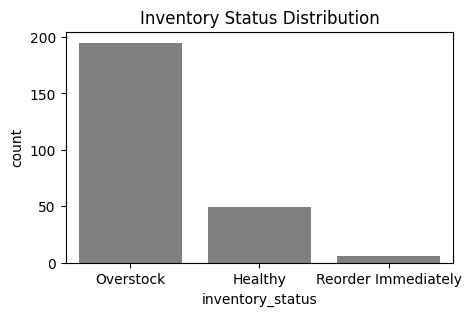

In [20]:
plt.figure(figsize=(5,3))
sns.countplot(x='inventory_status',data=inventory_df, order=inventory_df['inventory_status'].value_counts().index, color='grey')

plt.title("Inventory Status Distribution")
plt.show()

- nearly 80% of inventory combinations are overstocked.
- around 20% maintain healthy inventory levels.
- very few SKUs require immediate replenishment.
- this indicates that the organization is primarily facing an **overstocking** problem rather than frequent stock shortages.

### Top 10 SKUs requiring re-ordering:

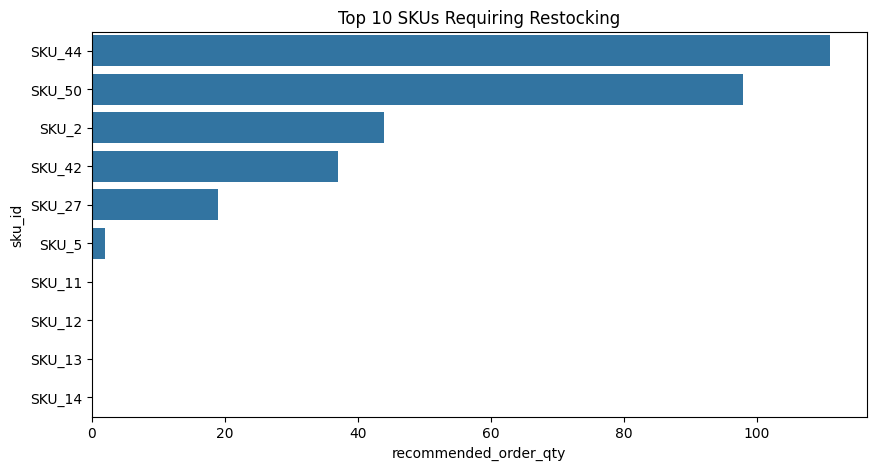

In [21]:
top10_reorder= inventory_df.sort_values('recommended_order_qty', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='recommended_order_qty', y='sku_id', data=top10_reorder)
plt.title("Top 10 SKUs Requiring Restocking")
plt.show()

### Top overstocked SKUs:

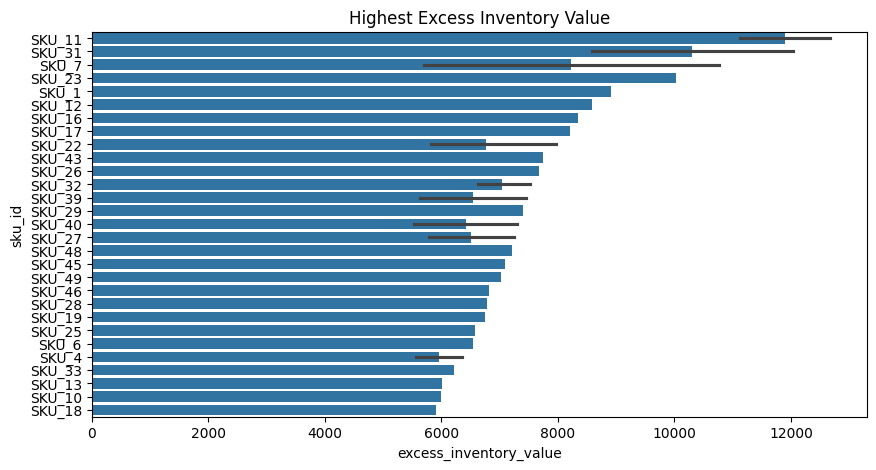

In [24]:
overstock = inventory_df.sort_values('excess_inventory_value', ascending=False).head(40)

plt.figure(figsize=(10,5))
sns.barplot(x='excess_inventory_value',y='sku_id', data=overstock)
plt.title("Highest Excess Inventory Value")
plt.show()

#### inventory gap:

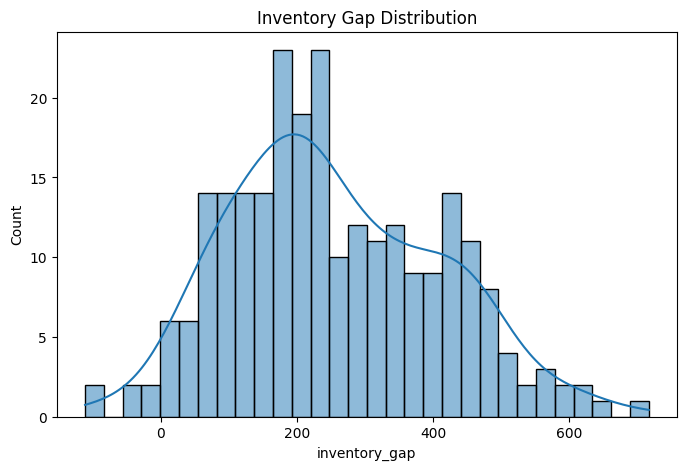

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(inventory_df['inventory_gap'],bins=30,kde=True)
plt.title("Inventory Gap Distribution")
plt.show()

- most inventory gaps are positive, indicating inventory generally exceeds recommended reorder levels.
- only a small number of observations fall below zero, representing potential understock situations.
- the overall distribution further supports that overstocking is the dominant issue.

#### excess inventory value as per each warehouse

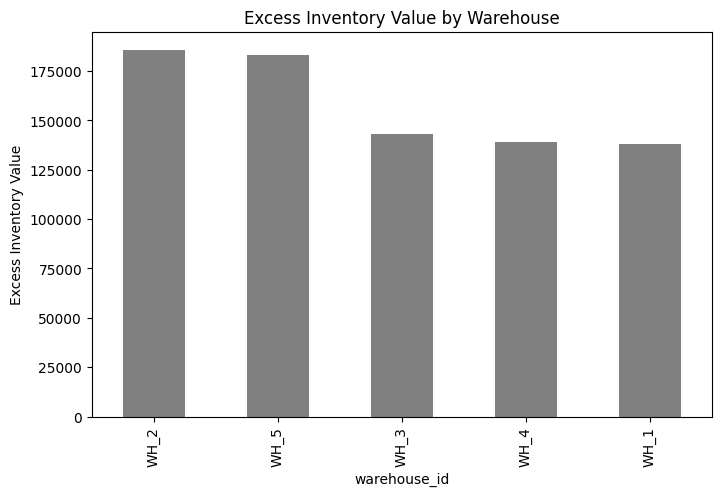

In [30]:
warehouse_cost = inventory_df.groupby('warehouse_id')['excess_inventory_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
warehouse_cost.plot(kind='bar', color='grey')
plt.ylabel("Excess Inventory Value")
plt.title("Excess Inventory Value by Warehouse")
plt.show()

- warehouses WH_2 and WH_5 contain the highest excess inventory value.
- these locations should be prioritized for inventory balancing and procurement optimization.
- redistributing inventory between warehouses could reduce unnecessary holding costs.

#### final recommendation table:

In [31]:
recommendations= inventory_df[['warehouse_id','sku_id','current_inventory','recommended_reorder_point','recommended_order_qty','inventory_status']]
recommendations.head(20)

,warehouse_id,sku_id,current_inventory,recommended_reorder_point,recommended_order_qty,inventory_status
0,WH_1,SKU_1,624,341.709529,0.0,Overstock
1,WH_1,SKU_10,503,314.716157,0.0,Overstock
2,WH_1,SKU_11,758,109.871817,0.0,Overstock
3,WH_1,SKU_12,304,135.635043,0.0,Overstock
4,WH_1,SKU_13,442,228.372919,0.0,Overstock
5,WH_1,SKU_14,457,264.081295,0.0,Overstock
6,WH_1,SKU_15,340,314.842457,0.0,Healthy
7,WH_1,SKU_16,466,336.846567,0.0,Healthy
8,WH_1,SKU_17,500,243.651517,0.0,Overstock
9,WH_1,SKU_18,407,62.468071,0.0,Overstock


- exporting:

In [32]:
recommendations.to_csv("inventory_recommendations.csv",index=False)

### Conclusion:
The analysis revealed that the organization experiences substantially more overstocking than stock shortages, resulting in approximately $788k of excess inventory value. The generated recommendation table can be directly integrated into an inventory planning dashboard or decision-support system to assist planners in reducing holding costs while maintaining adequate service levels.

In [33]:
inventory_df.to_csv("inventory_optimization.csv",index=False)

In [34]:
inventory_df.columns

Index(['warehouse_id', 'sku_id', 'current_inventory', 'avg_daily_demand',
       'demand_std', 'lead_time', 'unit_cost', 'unit_price', 'safety_stock',
       'lead_time_demand', 'recommended_reorder_point',
       'recommended_order_qty', 'inventory_status', 'inventory_gap',
       'excess_units', 'excess_inventory_value'],
      dtype='object')